In [68]:
from sklearn.datasets import make_circles,make_blobs
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sns

In [69]:
def plot_decision_boundary_1(model, X, y):
  """
  Plots the decision boundary created by a model predicting on X.
  This function has been adapted from two phenomenal resources:
   1. CS231n - https://cs231n.github.io/neural-networks-case-study/
   2. Made with ML basics - https://github.com/GokuMohandas/MadeWithML/blob/main/notebooks/08_Neural_Networks.ipynb
  """
  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X values (we're going to predict on all of these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together: https://numpy.org/devdocs/reference/generated/numpy.c_.html

  # Make predictions using the trained model
  y_pred = model.predict(x_in)

  # Check for multi-class
  if model.output_shape[-1] > 1: # checks the final dimension of the model's output shape, if this is > (greater than) 1, it's multi-class
    print("doing multiclass classification...")
    # We have to reshape our predictions to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classifcation...")
    y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)

  # Plot decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())



In [70]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    preds = np.round(preds).reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Linear Decision Boundary")
    plt.show()


In [71]:
#making 1000 examples
n_samples = 1000

#creating circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)


In [72]:
circles = pd.DataFrame({"X0":X[:, 0], "X1": X[:, 1], "label": y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


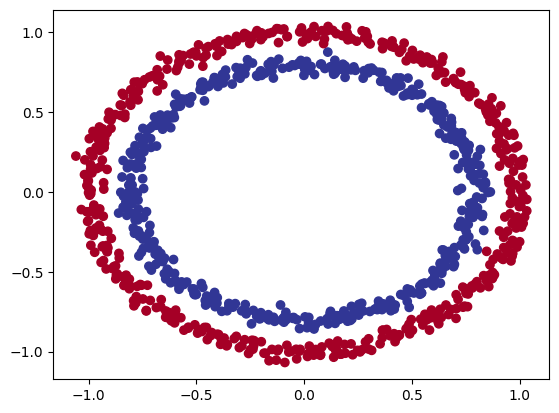

In [73]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [64]:
# Setting random seed
tf.random.set_seed(42)

# 1. Creating the model using the Sequential API
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# 2. Compilingt the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(), # binary since we are working with 2 clases (0 & 1)
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

# 3. Fitting the model
model_1.fit(X, y, epochs=1000)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.4730 - loss: 4.6010
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step - accuracy: 0.4870 - loss: 2.3314
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step - accuracy: 0.4950 - loss: 0.7487
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step - accuracy: 0.4920 - loss: 0.7091
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - accuracy: 0.4960 - loss: 0.6987
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.4940 - loss: 0.6956
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - accuracy: 0.4930 - loss: 0.6946
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.4810 - loss: 0.6944
Epoch 9/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 0.6943
Epoch 10/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - accuracy: 0.4780 - loss: 0.6943
Epoch 11/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.4560 - loss: 0.6943
Epoch 12/1000
32/32 ━━━━━━━━━━━━

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - accuracy: 0.4540 - loss: 0.6932


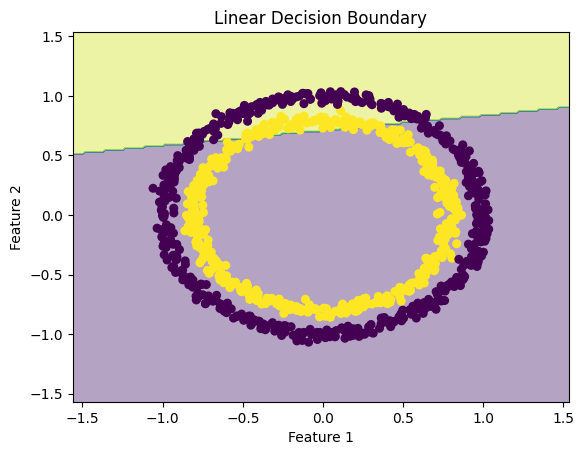

In [79]:
tf.random.set_seed(42)
model_2_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1), # add an extra layer
  tf.keras.layers.Dense(1)
])
model_2_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])
model_2_1.fit(X, y, epochs=100, verbose=0)
model_2_1.evaluate(X, y)
plot_decision_boundary(model_2_1, X, y)

In [77]:
tf.random.set_seed(42)
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1), # add an extra layer
  tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])
model_2.fit(X, y, epochs=100, verbose=0)
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.4970 - loss: 0.6932


[0.693233847618103, 0.4970000088214874]

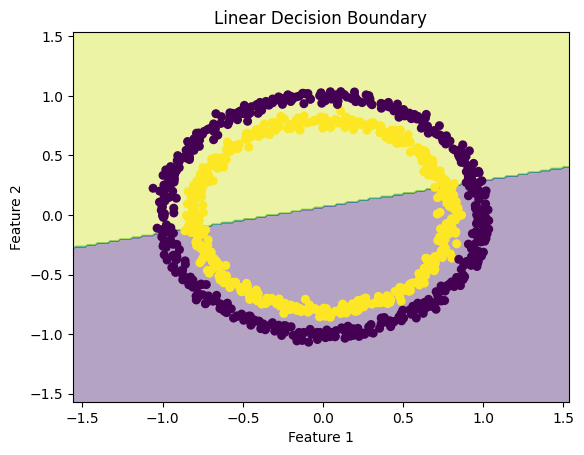

In [78]:
plot_decision_boundary(model_2, X, y)

<h2>When it just Dense and without mentioning the activation function, it becomes a linear model. thats why accuracy is so bad</h2>

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*ji2eu4xhi_puoMYXHEbAmg.png" />

<h2>Add more hidden layers</h2>

In [43]:
tf.random.set_seed(42)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])
model_2.fit(X, y, epochs=100, verbose=0)
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - accuracy: 0.8900 - loss: 0.4776


[0.4776493310928345, 0.8899999856948853]

<h2>Add learning rate</h2>

In [82]:
# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

tf.random.set_seed(42)
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                 optimizer=tf.keras.optimizers.SGD(learning_rate=0.05),
                metrics=['accuracy'])
history=model_4.fit(X_train, y_train, epochs=100, verbose=0)
loss, accuracy =model_4.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - accuracy: 1.0000 - loss: 0.0133


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 219us/step
doing binary classifcation...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 163us/step
doing binary classifcation...


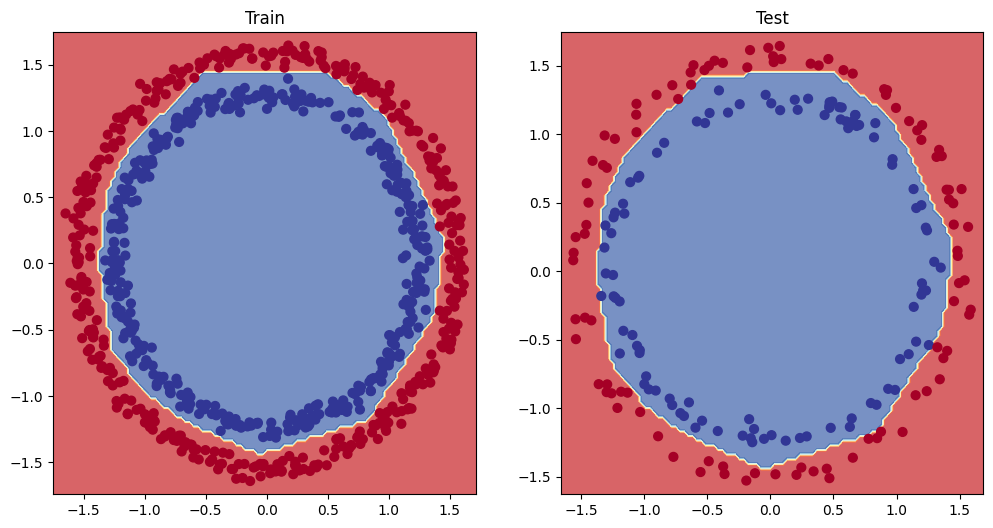

In [83]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary_1(model_4, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary_1(model_4, X_test, y_test)

plt.show()

Text(0.5, 1.0, 'model_4 training curves')

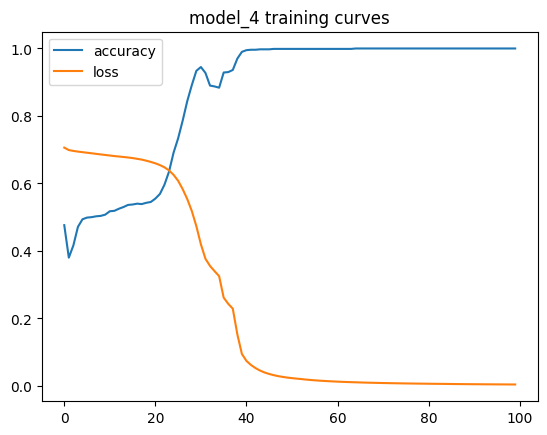

In [84]:
pd.DataFrame(history.history).plot()
plt.title("model_4 training curves")

<h2>Use adam optmizor</h2>

In [21]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
  # Before TensorFlow 2.7.0
  # tf.keras.layers.Dense(100), # add 100 dense neurons

  # With TensorFlow 2.7.0
  # tf.keras.layers.Dense(100, input_shape=(None, 1)), # add 100 dense neurons

  ## After TensorFlow 2.8.0 ##
  tf.keras.layers.Dense(100), # add 100 dense neurons
  tf.keras.layers.Dense(10), # add another layer with 10 neurons
  tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(), # use Adam instead of SGD
                metrics=['accuracy'])

# 3. Fit the model
model_3.fit(X, y, epochs=100, verbose=1) # fit for 100 passes of the data

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 474us/step - accuracy: 0.4570 - loss: 2.2897 
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - accuracy: 0.4830 - loss: 0.6993
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.4990 - loss: 0.6970
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.4930 - loss: 0.6942
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step - accuracy: 0.4760 - loss: 0.6940
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step - accuracy: 0.4630 - loss: 0.6941
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step - accuracy: 0.4830 - loss: 0.6943
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.4840 - loss: 0.6944
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - accuracy: 0.4820 - loss: 0.6945
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - accuracy: 0.4790 - loss: 0.6946
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - accuracy: 0.4800 - loss: 0.6947
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 

<h2>Use a different batch size</h2>
<p>32 is default in keras</p>

In [23]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
  # Before TensorFlow 2.7.0
  # tf.keras.layers.Dense(100), # add 100 dense neurons

  # With TensorFlow 2.7.0
  # tf.keras.layers.Dense(100, input_shape=(None, 1)), # add 100 dense neurons

  ## After TensorFlow 2.8.0 ##
  tf.keras.layers.Dense(100), # add 100 dense neurons
  tf.keras.layers.Dense(10), # add another layer with 10 neurons
  tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(), # use Adam instead of SGD
                metrics=['accuracy'])

# 3. Fit the model
model_3.fit(X, y, epochs=100, verbose=1, batch_size=64) # fit for 100 passes of the data

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step - accuracy: 0.4670 - loss: 3.5101
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - accuracy: 0.4610 - loss: 0.7590
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.4990 - loss: 0.7219
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.5040 - loss: 0.7048
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - accuracy: 0.5300 - loss: 0.6937
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - accuracy: 0.5600 - loss: 0.6932
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.4980 - loss: 0.6937
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - accuracy: 0.4910 - loss: 0.6937
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - accuracy: 0.4790 - loss: 0.6937
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - accuracy: 0.4760 - loss: 0.6937
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.4770 - loss: 0.6937
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0

<h1>Linear seperable data</h1>

In [46]:
# 1. Create linearly separable data
X, y = make_blobs(
    n_samples=1000,
    centers=2,
    n_features=2,
    cluster_std=1.0,
    random_state=42
)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [54]:
# 4. Build a simple binary classification model
tf.random.set_seed(42)

l_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 5. Compile
l_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    metrics=["accuracy"]
)

# 6. Train
history =l_model.fit(X_train, y_train, epochs=100, verbose=0)

# 7. Evaluate
l_model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 1.0000 - loss: 0.0028


[0.0028044315986335278, 1.0]

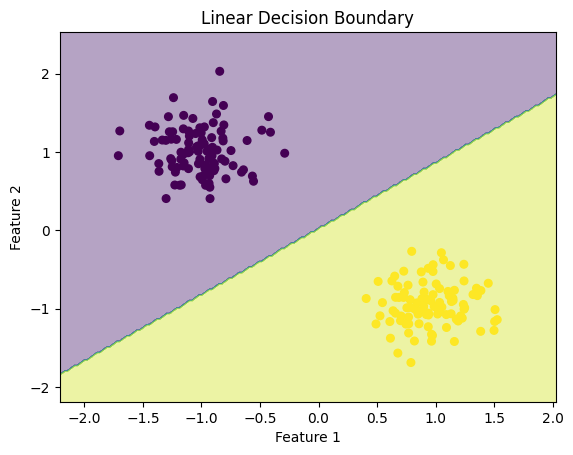

In [49]:

plot_decision_boundary(l_model, X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


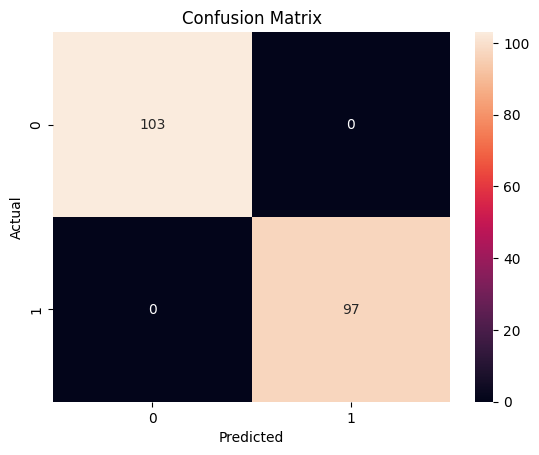

In [53]:
y_probs = l_model.predict(X_test)
y_preds = (y_probs > 0.5).astype(int)

cnf_matrix = metrics.confusion_matrix(y_test, y_preds)
tn, fp, fn, tp = cnf_matrix.ravel()

plt.figure()
sns.heatmap(cnf_matrix, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [56]:
history.history

{'accuracy': [0.5037500262260437,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'loss': [0.8010058403015137,
  0.23123933374881744,
  0.12793411314487457,
  0.08855175226926804,
  0.06792087107896805,
  0.055232394486665726,
  0.046636227518320084,
  0.0404232032597065,
  0.0357196219265461,
  0.0320325642824173,
  0.029062874615192413,
  0.02661843

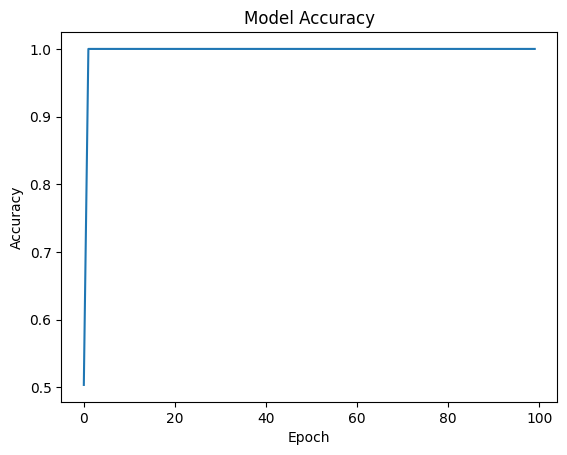

In [55]:
plt.plot(history.history['accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.show()

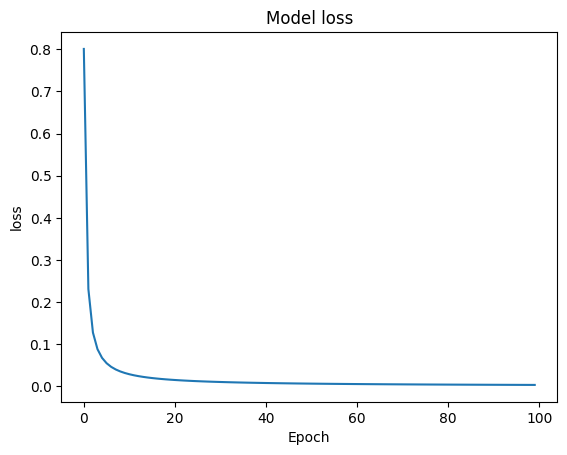

In [57]:
plt.plot(history.history['loss'])

plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Model loss")

plt.show()